Objetivo:
Evaluar si la dependencia condicional detectada entre petroleras y petróleo
puede convertirse en una estrategia rentable.

Hipótesis:
Cuando una petrolera sube significativamente,
el petróleo presenta retornos positivos posteriores.


In [21]:
from data_utils import load_data

df, returns = load_data()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [22]:
threshold = 0.01

signal = (
    (returns["rep"] > threshold) |
    (returns["bp"] > threshold) |
    (returns["shell"] > threshold) |
    (returns["exxon"] > threshold) |
    (returns["chevron"] > threshold)
).astype(int)

position = signal.shift(1).fillna(0)

In [24]:
strategy = returns["oil"] * position

cum_strategy = (1 + strategy).cumprod()
cum_oil = (1 + returns["oil"]).cumprod()


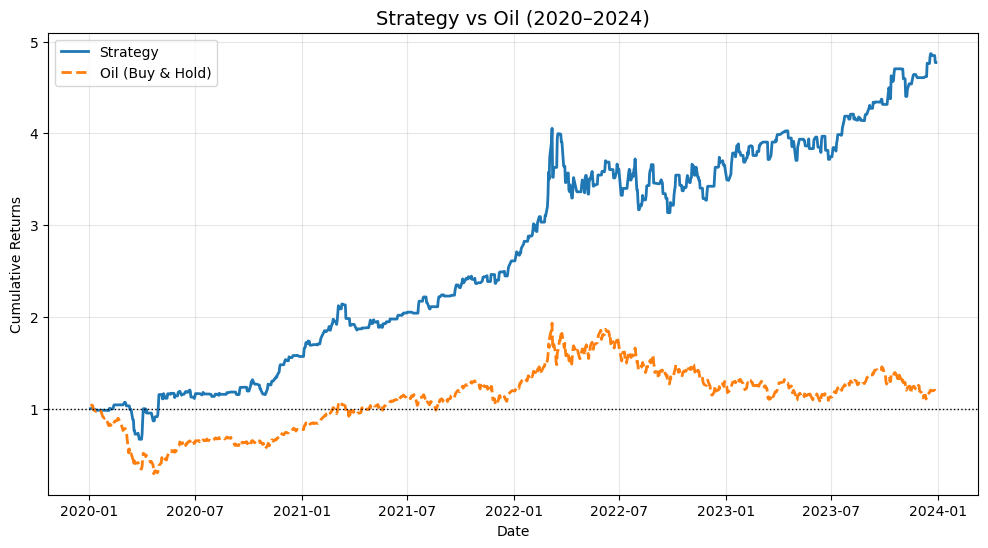

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))


plt.plot(cum_strategy, label="Strategy", linewidth=2)
plt.plot(cum_oil, label="Oil (Buy & Hold)", linestyle="--", linewidth=2)


plt.title("Strategy vs Oil (2020–2024)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")


plt.grid(alpha=0.3)


plt.legend()


plt.axhline(1, color="black", linewidth=1, linestyle=":")

plt.show()

In [6]:
sharpe = strategy.mean() / strategy.std()

drawdown = (cum_strategy / cum_strategy.cummax() - 1).min()

print("Return:", cum_strategy.iloc[-1])
print("Sharpe:", sharpe)
print("Max Drawdown:", drawdown)

Return: 4.770946991336889
Sharpe: 0.08793083623871019
Max Drawdown: -0.377047859568012


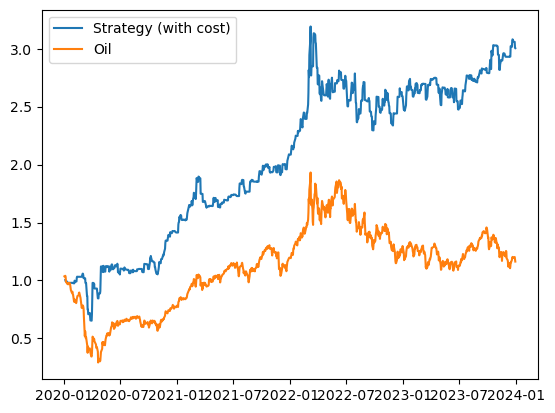

In [7]:
cost = 0.001

strategy_cost = strategy - cost * position.diff().abs()

cum_strategy_cost = (1 + strategy_cost).cumprod()

plt.plot(cum_strategy_cost, label="Strategy (with cost)")
plt.plot(cum_oil, label="Oil")
plt.legend()
plt.show()

In [8]:
for t in [0.005, 0.01, 0.02]:
    
    signal = (
        (returns["shell"] > t)
    ).astype(int)
    
    pos = signal.shift(1).fillna(0)
    
    strat = returns["oil"] * pos
    
    print(t, (1 + strat).cumprod().iloc[-1])

0.005 2.571608329493553
0.01 2.4728642102447678
0.02 1.4394379002404243


In [9]:
periods = [
    ("2020-01-01","2021-01-01"),
    ("2021-01-01","2022-01-01"),
    ("2022-01-01","2023-01-01"),
    ("2023-01-01","2024-01-01"),
]

for start, end in periods:
    
    sub = returns.loc[start:end]
    
    signal = (sub["shell"] > 0.01).astype(int)
    pos = signal.shift(1).fillna(0)
    
    strat = sub["oil"] * pos
    
    print(start, end, (1 + strat).cumprod().iloc[-1])

2020-01-01 2021-01-01 1.185650554179417
2021-01-01 2022-01-01 1.5745771111126157
2022-01-01 2023-01-01 1.059386894560138
2023-01-01 2024-01-01 1.2503310903565155


Conclusiones:

- La estrategia muestra rentabilidad en ciertos periodos
- Existe dependencia de régimen de mercado
- La señal es débil pero explotable bajo ciertas condiciones

Limitaciones:

- posible overfitting
- costes pueden afectar significativamente
- dependencia del ciclo energético
"""